Gaze-Based Interface for physically disabled users.

In [ ]:
# ======================================
# 1. Mount Google Drive
# ======================================
# This allows us to access datasets and files stored in your Google Drive directly from Colab.

from google.colab import drive

# Mount the drive at the specified path
drive.mount('/content/drive')

print("\nGoogle Drive mounted successfully. Files can now be accessed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Google Drive mounted successfully. Files can now be accessed.


In [ ]:
# ======================================
# 2. Verify Dataset Directory
# ======================================
import os

DATASET_PATH = "/content/drive/MyDrive/Gaze detection/"

# Check if path exists
if os.path.exists(DATASET_PATH):
    print("Dataset directory found.\n")
    print("Contents of the dataset directory:")
    for item in os.listdir(DATASET_PATH):
        print(f" - {item}")
else:
    print("Dataset directory not found. Please check the path.")

Dataset directory found.

Contents of the dataset directory:
 - X_mpiigaze_normalized.mat
 - Y_mpiigaze_gaze.mat


In [ ]:
# ======================================
# 3. Check Individual Dataset Files
# ======================================
import os

X_FILE_PATH = "/content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat"
Y_FILE_PATH = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"

# Check if each file exists and print a clear message
if os.path.exists(X_FILE_PATH):
    print(f"Found X dataset file: {X_FILE_PATH}")
else:
    print(f"X dataset file not found at: {X_FILE_PATH}")

if os.path.exists(Y_FILE_PATH):
    print(f"Found Y dataset file: {Y_FILE_PATH}")
else:
    print(f"Y dataset file not found at: {Y_FILE_PATH}")

Found X dataset file: /content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat
Found Y dataset file: /content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat


In [ ]:
# ======================================
# 4. Inspect Dataset Files
# ======================================
import os
import h5py
import numpy as np

# Paths to the dataset files
X_PATH = "/content/drive/MyDrive/Gaze detection/X_mpiigaze_normalized.mat"
Y_PATH = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"

# 4a. Check size of Y dataset file
y_size_bytes = os.path.getsize(Y_PATH)
y_size_mb = y_size_bytes / (1024 * 1024)
print(f"Size of Y dataset file: {y_size_mb:.2f} MB")

# 4b. Open the X dataset file using h5py
X_file = h5py.File(X_PATH, 'r')

# List all datasets/keys inside the X file
x_keys = list(X_file.keys())
print("\nDatasets available inside X file:")
for key in x_keys:
    print(f" - {key}")

Size of Y dataset file: 9.17 MB

Datasets available inside X file:
 - X


In [ ]:
# ======================================
# 5. Load and Inspect Dataset Shapes
# ======================================
import scipy.io

# ---- Load X dataset ----
X = X_file['X']  # Access the dataset inside the .mat file
print(f"Shape of X dataset: {X.shape}")

# ---- Load Y dataset ----
Y_path = "/content/drive/MyDrive/Gaze detection/Y_mpiigaze_gaze.mat"
Y_data = scipy.io.loadmat(Y_path)

print("\nKeys inside Y dataset file:")
for key in Y_data.keys():
    print(f" - {key}")  # just to confirm keys

# Extract the actual Y data
Y = Y_data['Y']  # Ensure this key matches
print(f"\nShape of Y dataset: {Y.shape}")

Shape of X dataset: (427316, 64, 64)

Keys inside Y dataset file:
 - __header__
 - __version__
 - __globals__
 - Y

Shape of Y dataset: (427316, 3)


In [45]:
# ======================================
# Final Model Architecture Table
# ======================================

import pandas as pd

layers_data = []

for layer in model.layers:
    layers_data.append({
        "Layer Name": layer.name,
        "Layer Type": layer.__class__.__name__,
        "Output Shape": layer.output.shape,
        "Parameters": layer.count_params()
    })

architecture_df = pd.DataFrame(layers_data)

# Add total row
total_row = pd.DataFrame([{
    "Layer Name": "TOTAL",
    "Layer Type": "-",
    "Output Shape": "-",
    "Parameters": model.count_params()
}])

architecture_df = pd.concat([architecture_df, total_row], ignore_index=True)

architecture_df

,Layer Name,Layer Type,Output Shape,Parameters
0,conv2d,Conv2D,"(None, 62, 62, 32)",320
1,max_pooling2d,MaxPooling2D,"(None, 31, 31, 32)",0
2,conv2d_1,Conv2D,"(None, 29, 29, 64)",18496
3,max_pooling2d_1,MaxPooling2D,"(None, 14, 14, 64)",0
4,conv2d_2,Conv2D,"(None, 12, 12, 128)",73856
5,max_pooling2d_2,MaxPooling2D,"(None, 6, 6, 128)",0
6,flatten,Flatten,"(None, 4608)",0
7,dense,Dense,"(None, 128)",589952
8,dense_1,Dense,"(None, 3)",387
9,lambda,Lambda,"(None, 3)",0


In [ ]:
# ======================================
# Inspect Dataset Shape
# ======================================

with h5py.File(X_PATH, 'r') as X_file:
    print("Available datasets:", list(X_file.keys()))
    print("Shape of X:", X_file['X'].shape)

Available datasets: ['X']
Shape of X: (427316, 64, 64)


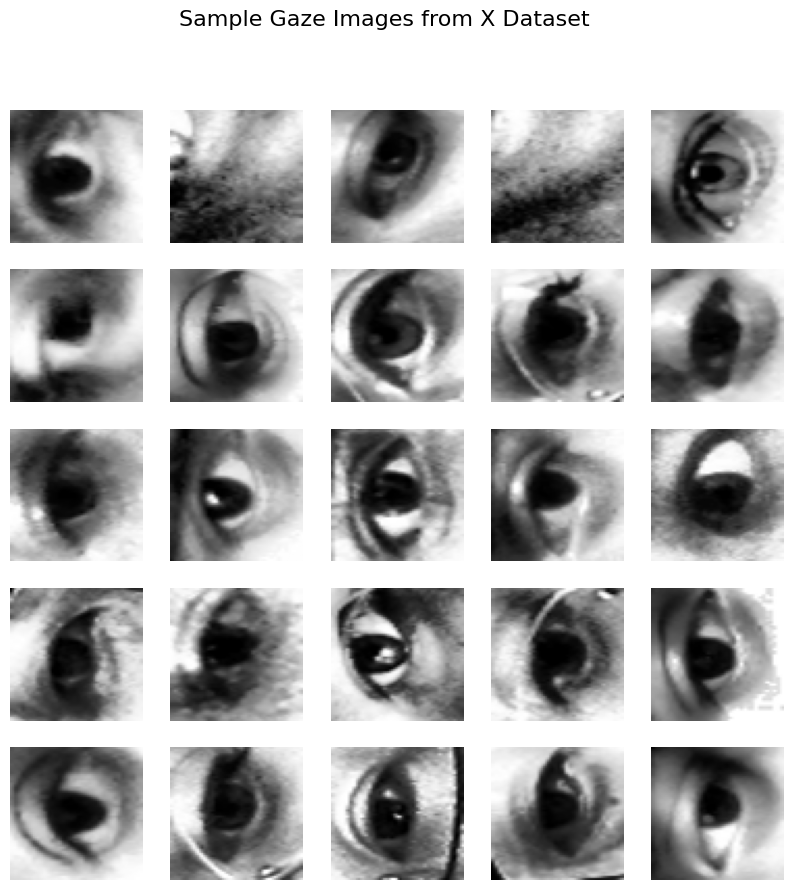

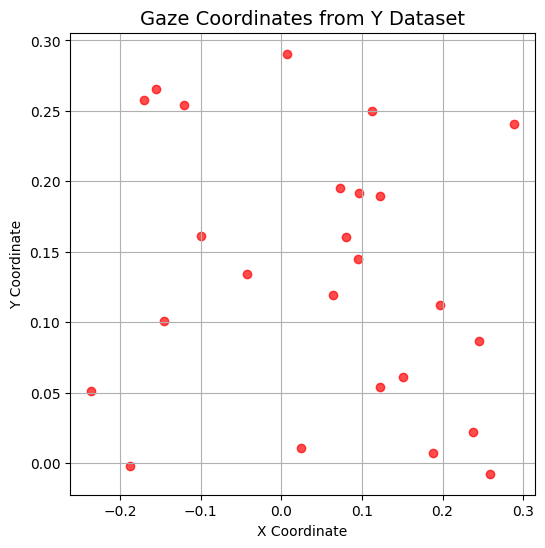

In [ ]:
# ======================================
# 6. Visualize Sample Gaze Data
# ======================================
import matplotlib.pyplot as plt
import random

# ---- Visualize a random selection of 25 gaze images ----
num_samples_to_show = 25
indices = random.sample(range(X.shape[0]), num_samples_to_show)

plt.figure(figsize=(10,10))
for i, idx in enumerate(indices):
    plt.subplot(5,5,i+1)
    plt.imshow(X[idx], cmap='gray')  # assuming grayscale images
    plt.axis('off')
plt.suptitle("Sample Gaze Images from X Dataset", fontsize=16)
plt.show()

# ---- Visualize corresponding gaze points from Y ----
# Assuming Y has shape (num_samples, 2) with (x, y) coordinates
sample_Y = Y[indices]

plt.figure(figsize=(6,6))
plt.scatter(sample_Y[:,0], sample_Y[:,1], c='red', alpha=0.7)
plt.title("Gaze Coordinates from Y Dataset", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

Sampled X shape: (20000, 64, 64)
Sampled Y shape: (20000, 3)


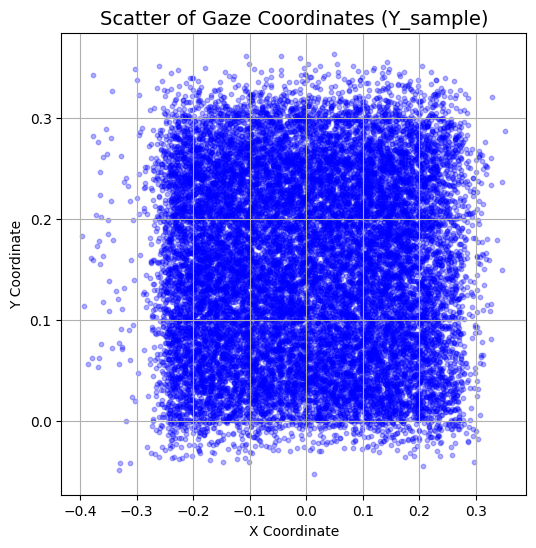

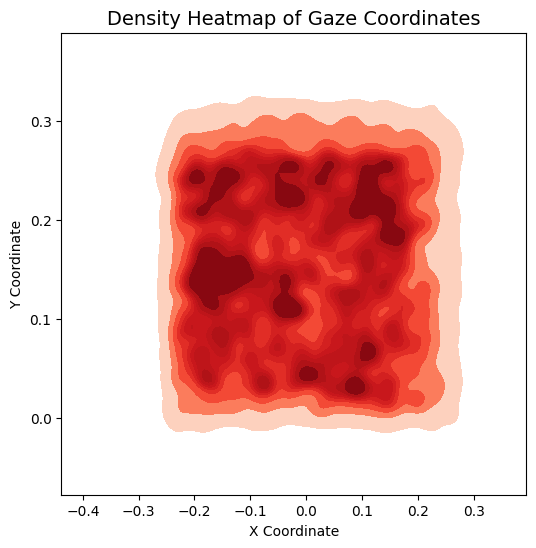

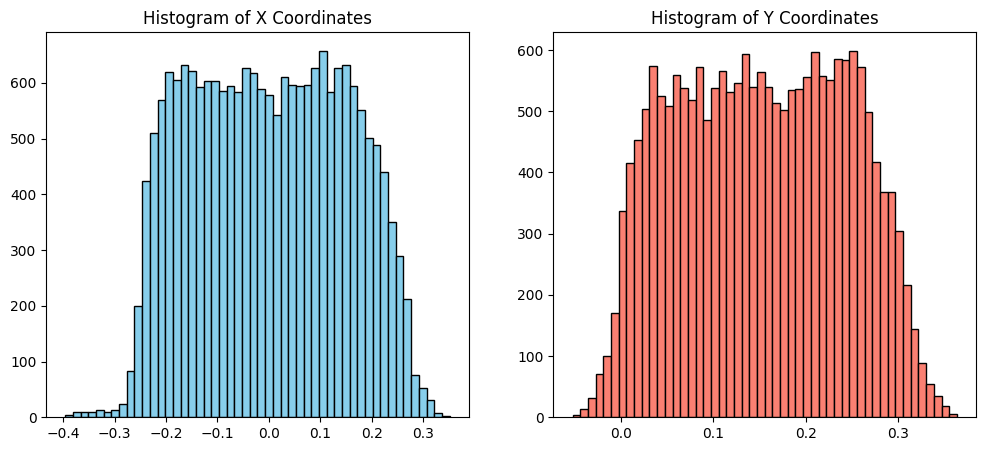

In [ ]:
# ======================================
# 7. Visualize Gaze Coordinates Distribution
# ======================================

import numpy as np

num_samples = 20000
indices = np.random.choice(X.shape[0], num_samples, replace=False)
indices = np.sort(indices)

X_sample = X[indices].astype("float32")
Y_sample = Y[indices]

print(f"Sampled X shape: {X_sample.shape}")
print(f"Sampled Y shape: {Y_sample.shape}")
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of all sampled gaze points
plt.figure(figsize=(6,6))
plt.scatter(Y_sample[:,0], Y_sample[:,1], c='blue', alpha=0.3, s=10)
plt.title("Scatter of Gaze Coordinates (Y_sample)", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

# Heatmap / density of gaze points
plt.figure(figsize=(6,6))
sns.kdeplot(
    x=Y_sample[:,0], y=Y_sample[:,1],
    fill=True, cmap='Reds', bw_adjust=0.5, thresh=0.05
)
plt.title("Density Heatmap of Gaze Coordinates", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

# Optional: histogram for X and Y coordinates separately
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(Y_sample[:,0], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of X Coordinates")
plt.subplot(1,2,2)
plt.hist(Y_sample[:,1], bins=50, color='salmon', edgecolor='black')
plt.title("Histogram of Y Coordinates")
plt.show()

In [ ]:
# ======================================
# 8. Explore and Split Sampled Dataset
# ======================================
import numpy as np
from sklearn.model_selection import train_test_split

# Check the range of values in X_sample
print(f"🔹 X_sample range: min = {X_sample.min():.4f}, max = {X_sample.max():.4f}")

# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X_sample, Y_sample,
    test_size=0.2,   # 20% for testing
    random_state=42  # ensures reproducibility
)

# ---- Print shapes of all splits ----
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

🔹 X_sample range: min = 0.0000, max = 1.0000
X_train shape: (16000, 64, 64)
Y_train shape: (16000, 3)
X_test shape: (4000, 64, 64)
Y_test shape: (4000, 3)


In [ ]:
# ======================================
# 9. Inspect Y_sample & Install TensorFlow
# ======================================
import numpy as np
import sys
import tensorflow as tf

# Check the average magnitude of gaze vectors
mean_norm = np.mean(np.linalg.norm(Y_sample, axis=1))
print(f"🔹 Average magnitude of gaze vectors in Y_sample: {mean_norm:.4f}")

# Upgrade pip
!{sys.executable} -m pip install --upgrade pip

# Install TensorFlow (specific version)
!{sys.executable} -m pip install tensorflow
# Uninstall any conflicting versions
!pip uninstall -y tensorflow tensorflow-cpu tensorboard
!pip uninstall -y tensorflow tensorflow-cpu tensorboard
# Install desired version
!pip install tensorflow==2.20.0

# Import TensorFlow and check version
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

🔹 Average magnitude of gaze vectors in Y_sample: 1.0000
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorboard 2.20.0
Uninstalling tensorboard-2.20.0:
  Successfully uninstalled tensorboard-2.20.0
  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decis

TensorFlow version: 2.20.0


In [ ]:
# ======================================
# 10. Normalize Gaze Vectors for Training
# ======================================
import numpy as np
import tensorflow as tf

# ---- Normalize Y_train and Y_test ----
# Each gaze vector is scaled to unit length
Y_train_norm = Y_train / np.linalg.norm(Y_train, axis=1, keepdims=True)
Y_test_norm  = Y_test  / np.linalg.norm(Y_test, axis=1, keepdims=True)

# ---- Verify normalization ----
print(f"🔹 Example normalized gaze vector (first sample): {Y_train_norm[0]}")
print(f"🔹 Norm of first sample vector: {np.linalg.norm(Y_train_norm[0]):.4f}")

🔹 Example normalized gaze vector (first sample): [ 0.12657321  0.11183451 -0.98563293]
🔹 Norm of first sample vector: 1.0000


In [ ]:
# ======================================
# Gaze Label Distribution Table
# ======================================

import pandas as pd
import numpy as np
label_stats = pd.DataFrame({
    "Statistic": ["Mean X", "Mean Y", "Mean Z",
                  "Std X", "Std Y", "Std Z"],
    "Value": [
        np.mean(Y_train_norm[:,0]),
        np.mean(Y_train_norm[:,1]),
        np.mean(Y_train_norm[:,2]),
        np.std(Y_train_norm[:,0]),
        np.std(Y_train_norm[:,1]),
        np.std(Y_train_norm[:,2])
    ]
})

label_stats

,Statistic,Value
0,Mean X,0.000358
1,Mean Y,0.152157
2,Mean Z,-0.972995
3,Std X,0.147231
4,Std Y,0.090113
5,Std Z,0.018189


In [ ]:
# ======================================
# 11. Build CNN Model for Gaze Prediction
# ======================================
from tensorflow.keras import layers, models
import tensorflow as tf

# Sequential CNN architecture
# Input: 64x64 grayscale eye image
# Output: 3D normalized gaze vector

model = models.Sequential([

    # First convolution block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(2,2),

    # Second convolution block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Third convolution block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output 3D gaze vector
    layers.Dense(3),

    # Normalize output to unit vector
    layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print(X_train.shape)

(16000, 64, 64)


In [ ]:
# ======================================
# Dataset Information Table
# ======================================

import pandas as pd

channels = X_train.shape[3] if len(X_train.shape) == 4 else 1

dataset_df = pd.DataFrame({
    "Metric": [
        "Training Samples",
        "Testing Samples",
        "Image Resolution",
        "Input Channels",
        "Output Type"
    ],
    "Value": [
        X_train.shape[0],
        X_test.shape[0],
        f"{X_train.shape[1]} x {X_train.shape[2]}",
        channels,
        "3D Normalized Gaze Vector"
    ]
})

dataset_df

,Metric,Value
0,Training Samples,16000
1,Testing Samples,4000
2,Image Resolution,64 x 64
3,Input Channels,1
4,Output Type,3D Normalized Gaze Vector


In [ ]:
# ======================================
# 12. Define Cosine Similarity Loss
# ======================================

# Loss = 1 - cosine similarity
# Since outputs are normalized, this directly penalizes angular difference
def cosine_loss(y_true, y_pred):
    y_true = tf.math.l2_normalize(y_true, axis=1)
    y_pred = tf.math.l2_normalize(y_pred, axis=1)
    return 1 - tf.reduce_sum(y_true * y_pred, axis=1)

In [ ]:
# ======================================
# 13. Compile the Model
# ======================================

from tensorflow.keras import optimizers

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=cosine_loss
)

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow

In [ ]:
!pip uninstall -y tensorflow tensorflow-cpu tensorboard

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: tensorboard 2.20.0
Uninstalling tensorboard-2.20.0:
  Successfully uninstalled tensorboard-2.20.0


In [ ]:
!pip uninstall -y tensorflow tensorflow-cpu tensorboard

In [ ]:
!pip install tensorflow==2.20.0

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.


In [50]:
# ======================================
# Model Architecture Summary
# ======================================

# Display the complete architecture of the model.
# This includes:
# - Each layer name
# - Layer type (Conv2D, Dense, etc.)
# - Output shape after each layer
# - Number of trainable parameters per layer
# - Total trainable and non-trainable parameters

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049,035 (7.82 MB)

 Trainable params: 683,011 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,366,024 (5.21 MB)

In [ ]:
import tensorflow as tf
print(tf.__version__)  # should print 2.20.0

2.20.0


In [ ]:
# ======================================
# 14. Train the Model
# ======================================

history = model.fit(
    X_train,
    Y_train_norm,
    validation_data=(X_test, Y_test_norm),
    epochs=25,
    batch_size=64,
    verbose=1
)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 143s 548ms/step - loss: 0.0819 - val_loss: 0.0088
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 507ms/step - loss: 0.0083 - val_loss: 0.0066
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 146s 525ms/step - loss: 0.0063 - val_loss: 0.0056
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 122s 489ms/step - loss: 0.0054 - val_loss: 0.0051
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 147s 509ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 496ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 152s 536ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 517ms/step - loss: 0.0037 - val_loss: 0.0042
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 125s 500ms/step - loss: 0.0035 - val_loss: 0.0040
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 124s 497ms/step - loss: 0.0032 - val_loss: 0.0042
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 151s 533ms/step - loss: 0.0031 - val_loss: 0.0039
Epoch 12

In [ ]:
# ======================================
# Training Summary Table
# ======================================

training_summary = pd.DataFrame({
    "Metric": [
        "Final Training Loss",
        "Final Validation Loss",
        "Best Validation Loss",
        "Epochs Trained"
    ],
    "Value": [
        history.history['loss'][-1],
        history.history['val_loss'][-1],
        np.min(history.history['val_loss']),
        len(history.history['loss'])
    ]
})

training_summary

,Metric,Value
0,Final Training Loss,0.001328
1,Final Validation Loss,0.003481
2,Best Validation Loss,0.003386
3,Epochs Trained,25.000000


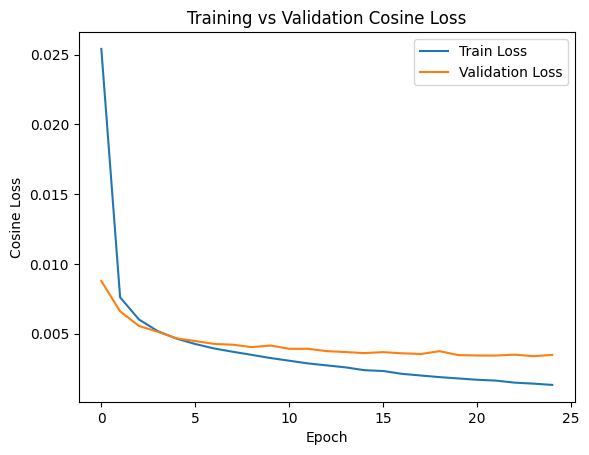

In [ ]:
# ======================================
# 15. Visualize Training vs Validation Loss
# ======================================

import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Cosine Loss")
plt.title("Training vs Validation Cosine Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.show()

In [ ]:
# ======================================
# 16. Evaluate Model using Angular Error
# ======================================

import numpy as np
import matplotlib.pyplot as plt

# ---- Generate Predictions ----
Y_pred = model.predict(X_test)

# ---- Compute Cosine Similarity ----
# Dot product between predicted and true normalized vectors
dot = np.sum(Y_pred * Y_test_norm, axis=1)

# Numerical stability (avoid arccos domain error)
dot = np.clip(dot, -1.0, 1.0)

# ---- Convert to Angular Error in Degrees ----
angles = np.degrees(np.arccos(dot))

# ---- Print Evaluation Metrics ----
print("Mean Angular Error (degrees):", np.mean(angles))
print("Median Angular Error (degrees):", np.median(angles))

125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step
Mean Angular Error (degrees): 3.7084226365741833
Median Angular Error (degrees): 2.97110787190518


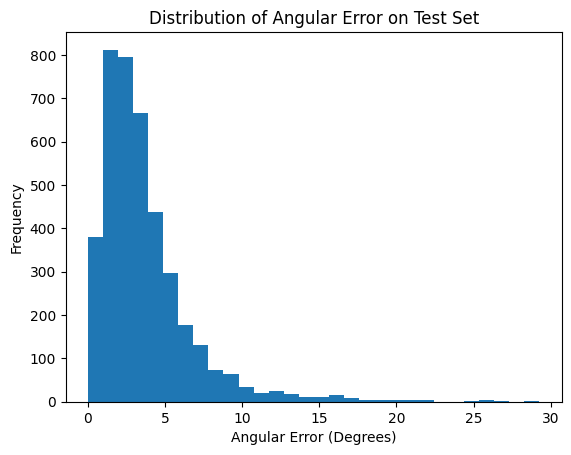

In [ ]:
# ======================================
# 17. Visualize Angular Error Distribution
# ======================================

plt.figure()
plt.hist(angles, bins=30)
plt.xlabel("Angular Error (Degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Angular Error on Test Set")
plt.show()

In [ ]:
# ======================================
# 18. Inspect Sample Predictions vs Ground Truth
# ======================================

# ---- Predict first 5 test samples ----
pred = model.predict(X_test[:5])

print("Predictions:")
print(pred)

print("\nGround Truth:")
print(Y_test[:5])


# ---- Compare Using Cosine Similarity ----
# Normalize ground truth to match model output format
true_norm = Y_test[:5] / np.linalg.norm(Y_test[:5], axis=1, keepdims=True)

dot = np.sum(pred * true_norm, axis=1)
dot = np.clip(dot, -1.0, 1.0)
angles = np.degrees(np.arccos(dot))

print("\nAngular Errors (degrees) for these 5 samples:")
print(angles)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
Predictions:
[[ 0.16867214  0.10626534 -0.97992724]
 [-0.23720694  0.17184709 -0.95613885]
 [ 0.09141137  0.11227874 -0.98946327]
 [-0.2314872   0.24492419 -0.9415018 ]
 [-0.04007914  0.30431494 -0.9517279 ]]

Ground Truth:
[[ 0.1680989   0.12170234 -0.97822865]
 [-0.25711331  0.1320685  -0.95731429]
 [ 0.08424738  0.10179111 -0.99123204]
 [-0.15388376  0.17665705 -0.97216875]
 [ 0.03828     0.26427441 -0.96368754]]

Angular Errors (degrees) for these 5 samples:
[0.89040422 2.54966633 0.73447599 6.18014602 5.08986907]


In [ ]:
# ======================================
# 19. Inspect Raw Loss Values
# ======================================

print("Training Loss per Epoch:")
print(history.history['loss'])

print("\nValidation Loss per Epoch:")
print(history.history['val_loss'])

Training Loss per Epoch:
[0.025406768545508385, 0.00760393962264061, 0.006021068897098303, 0.005185374990105629, 0.0046493057161569595, 0.004258906934410334, 0.003942940849810839, 0.00370364380069077, 0.0034820472355931997, 0.003255315124988556, 0.003063199808821082, 0.0028693508356809616, 0.0027272349689155817, 0.0025859177112579346, 0.0023832491133362055, 0.002325548091903329, 0.002121986821293831, 0.0020026834681630135, 0.001885883742943406, 0.001791971968486905, 0.0016968389973044395, 0.0016369172371923923, 0.0014908738667145371, 0.0014202051097527146, 0.0013276803074404597]

Validation Loss per Epoch:
[0.008779474534094334, 0.006598323117941618, 0.005556841380894184, 0.005135498009622097, 0.004663744475692511, 0.00447244755923748, 0.004268235992640257, 0.004209913779050112, 0.004035518039017916, 0.004150599706918001, 0.003915776964277029, 0.003914957866072655, 0.0037500832695513964, 0.0036831258330494165, 0.0036091601941734552, 0.0036770361475646496, 0.003594819223508239, 0.003543

In [ ]:
# ======================================
# 20. Additional Performance Metrics
# ======================================

import numpy as np

# Ensure predictions are normalized
Y_pred = model.predict(X_test)
Y_pred = Y_pred / np.linalg.norm(Y_pred, axis=1, keepdims=True)

# Normalize ground truth
Y_true = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)

# ---- Cosine Similarity ----
cos_sim = np.sum(Y_pred * Y_true, axis=1)

mean_cos_sim = np.mean(cos_sim)

# ---- Angular Error ----
cos_sim = np.clip(cos_sim, -1.0, 1.0)
angles = np.degrees(np.arccos(cos_sim))

mean_angle = np.mean(angles)
median_angle = np.median(angles)

# ---- RMSE (vector space) ----
rmse = np.sqrt(np.mean((Y_pred - Y_true) ** 2))

# ---- Percentage within threshold ----
within_10 = np.mean(angles < 10) * 100
within_20 = np.mean(angles < 20) * 100
within_30 = np.mean(angles < 30) * 100

print("Mean Cosine Similarity:", mean_cos_sim)
print("Mean Angular Error (deg):", mean_angle)
print("Median Angular Error (deg):", median_angle)
print("RMSE:", rmse)
print("% within 10°:", within_10)
print("% within 20°:", within_20)
print("% within 30°:", within_30)

125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step
Mean Cosine Similarity: 0.9965191698311824
Mean Angular Error (deg): 3.7083486482308627
Median Angular Error (deg): 2.9710739457115687
RMSE: 0.04817225717262774
% within 10°: 96.0
% within 20°: 99.65
% within 30°: 100.0


In [ ]:
print(history.history['loss'])
print(history.history['val_loss'])

[0.025406768545508385, 0.00760393962264061, 0.006021068897098303, 0.005185374990105629, 0.0046493057161569595, 0.004258906934410334, 0.003942940849810839, 0.00370364380069077, 0.0034820472355931997, 0.003255315124988556, 0.003063199808821082, 0.0028693508356809616, 0.0027272349689155817, 0.0025859177112579346, 0.0023832491133362055, 0.002325548091903329, 0.002121986821293831, 0.0020026834681630135, 0.001885883742943406, 0.001791971968486905, 0.0016968389973044395, 0.0016369172371923923, 0.0014908738667145371, 0.0014202051097527146, 0.0013276803074404597]
[0.008779474534094334, 0.006598323117941618, 0.005556841380894184, 0.005135498009622097, 0.004663744475692511, 0.00447244755923748, 0.004268235992640257, 0.004209913779050112, 0.004035518039017916, 0.004150599706918001, 0.003915776964277029, 0.003914957866072655, 0.0037500832695513964, 0.0036831258330494165, 0.0036091601941734552, 0.0036770361475646496, 0.003594819223508239, 0.0035431175492703915, 0.003744884394109249, 0.00346623221412